In [1]:
def projectDistZ(x1,x2,y1,y2,d12,z):
    mx = (x2-x1)/d12
    xProj = x1 + mx * z
    
    my = (y2-y1)/d12
    yProj = y1 + my * z
    
    return (xProj, yProj)

def get_theta_angles(x1, y1, x2, y2, d):
    import numpy as np
    thetaX = np.arctan((x2-x1)/d) #rad
    thetaY = np.arctan((y2-y1)/d) #rad
    return (thetaX, thetaY)

def file_loader(runs):
    from collections.abc import Iterable

    if not isinstance(runs, Iterable):
        runs = [runs]

    pos = []
    phs = []
    tmis = []
    qtots = []
    nclus = []
    info_pluss = []
    xinfos = []
    n_spill_list = []

    for run_number in runs:
        data_path = f'/eos/project/i/insulab-como/testBeam/TB_2025_06_T9_epBOOST/HDF5/run{run_number}.h5'
        with h5py.File(data_path, 'r', libver='latest', swmr=True) as hf:
            pos.append(np.array(hf['xpos']))
            phs.append(np.array(hf['digiPH']))
            tmis.append(np.array(hf['digiTime']))
            qtots.append(np.array(hf['qtot']))
            nclus.append(np.array(hf['nclu']))
            info_plus = np.array(hf['info_plus'])
            xinfo = np.array(hf['xinfo'])
            info_pluss.append(info_plus)
            xinfos.append(xinfo)

            n_spill = int(np.max(info_plus[:, 0]))
            n_spill_list.append(n_spill)
            print(f'Run {run_number} — N spill: {n_spill} — events: {len(hf["xpos"])} — evs/spill: {len(hf["xpos"]) / n_spill:.0f}')

    xpos = np.concatenate(pos, axis=0)
    ph = np.concatenate(phs, axis=0)
    tm = np.concatenate(tmis, axis=0)
    qtot = np.concatenate(qtots, axis=0)
    nclu = np.concatenate(nclus, axis=0)
    info_plus = np.concatenate(info_pluss, axis=0)
    xinfo = np.concatenate(xinfos, axis=0)

    logic_pos = (xpos[:, :6] > -1) & (xpos[:, :6] < 15)
    
    logic = logic_pos.all(axis = 1)
    xpos= xpos[logic]
    ph= ph[logic]
    tm= tm[logic]
    qtot= qtot[logic]
    nclu= nclu[logic]
    info_plus= info_plus[logic]
    xinfo= xinfo[logic]
    # Apply offsets
    xpos[:, 0] -= offset_x1
    xpos[:, 1] -= offset_y1
    xpos[:, 4] -= offset_x3
    xpos[:, 5] -= offset_y3

    x1 = xpos[:, 0]
    y1 = xpos[:, 1]
    x2 = xpos[:, 2]
    y2 = xpos[:, 3]
    x3 = xpos[:, 4]
    y3 = xpos[:, 5]

    Calibration = False
    if Calibration:
        q = -25.84
        m = 323.4
        ph[:, 2] = (ph[:, 2] - q) / m

    xcry, ycry = projectDistZ(x1, x2, y1, y2, d12, d1c)
    theta_x_in, theta_y_in = get_theta_angles(x1, y1, x2, y2, d12)
    theta_x_out, theta_y_out = get_theta_angles(xcry, ycry, x3, y3, dc3)

    ph_calo_photon = ph[:, 2]
    ph_cherry1 = ph[:, 0]

    total_spills = sum(n_spill_list)
    print(f"{runs} — TOTAL SPILLS: {total_spills} — TOTAL EVENTS: {len(x1)}")

    return xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1, \
           theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu, info_plus, xinfo


def canonical_type(typ):
    typ = typ.lower()
    if 'axis' in typ or 'aligned' in typ:
        return 'Axis'
    elif 'amorph' in typ:
        return 'Amorphous'
    elif 'conv' in typ:
        return 'Conventional'
    elif 'trans' in typ:
        return 'Transition'
    else:
        return 'Unknown'

def get_color(label):
    label = label.lower()  # per evitare distinzione maiuscole/minuscole
    if "axis" in label:
        return "tab:blue"
    elif "amorphous" in label:
        return "orange"
    elif "conventional" in label:
        return "darkslategrey"
    elif "positron" in label:
        return "hotpink"
    else:
        return "black"  # default color

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import h5py
from collections import defaultdict
from collections.abc import Iterable

# === Parametri di selezione ===
target_sample = "W100um" ## W12mm Hybrid 
target_energy = -2.86  # GeV 2.86  6 
CutTheta = True       # Applica taglio angolare
ifconventional = False # Includi tipo 'conventional' indipendentemente dal sample

# === OFFSET e DISTANZE ===
d12 = 330  # cm
d23 = 53.2 + 626  ##66.8
d1c = 330 + 53.2  # cm
dc3 = 626 ## 10.7 
d1calo = d1c + 779.2

# offset_x1 = 0.107
# offset_y1 = -2.21

## run number < 730360
# offset_x3 =   0.459 --- 0.484
# offset_y3 =   -2.031 --- -2.053
# run number > 730359

# offset_x3 =    1.125,
# offset_y3 =   -2.797

offset_x1, offset_y1 = 0.17853857345868965, -2.733923881801258
offset_x3, offset_y3 = 0.9931285159961187, -1.9627562570988997

# === CHAMBERS AND DECORATORS ===
range_chamber = ((0, 10), (0, 10))
bins2d = (100, 100)
mycmap = 'jet'

opt_hist = {'histtype': 'step', 'lw': 1.5, 'alpha': 0.8}
opts_2d = {"cmap": mycmap, "bins": bins2d}

# === LOGICAL THRESHOLDS ===
th_cherry1 = 20
th_cherry2 = 20

# === Caricamento file di configurazione ===
with open("run_config.json", "r") as f:
    run_config = json.load(f)

# === RAGGRUPPA PER TIPO (con sample ed energia selezionati) ===
group_by_type = defaultdict(list)
energies = {}
samples = {}
types = {}
x_cry_cuts = {}
y_cry_cuts = {}

for run_str, conf in run_config.items():
    try:
        sample = conf["sample"].strip().lower()
        typ = conf["type"].strip().lower()
        energy = float(conf["energy"])
        run = int(run_str)

        condition_sample = sample == target_sample.lower()
        condition_type = (typ == "conventional") if ifconventional else False
        condition_energy = abs(energy - target_energy) < 1e-3

        if (condition_sample or condition_type) and condition_energy:
            group_by_type[typ].append(run)
            samples[run] = sample
            types[run] = typ
            energies[run] = energy
            x_cry_cuts[run] = conf["x_cry_cut"]
            y_cry_cuts[run] = conf["y_cry_cut"]

    except Exception as e:
        print(f"⚠️ Errore in run {run_str}: {e}")

# === Output per confronto ===
print(f"\n📊 Confronto tra 'type' per sample = '{target_sample}', energy = {target_energy:.2f} GeV")
for typ, runs in group_by_type.items():
    print(f"- Type: {typ:15} → {len(runs)} run(s): {runs}")



📊 Confronto tra 'type' per sample = 'W100um', energy = -2.86 GeV
- Type: axial           → 3 run(s): [730378, 730384, 730385]
- Type: amorphous       → 2 run(s): [730379, 730383]
- Type: positron--ax    → 1 run(s): [730386]
- Type: positron--am    → 1 run(s): [730388]


In [3]:
# === CALCOLO THETA_CUT SOLO DAL PRIMO RUN PER GRUPPO ===
theta_crit_dict = {}
theta_cut_dict = {}

for runs in group_by_type.values():
    ref_run = runs[0]  # Usa solo il primo run come riferimento
    energy = energies[ref_run]
    theta_crit = np.sqrt(2 * 887 / (np.abs(energy) * 1e9))  # rad

    sample_str = samples[ref_run]
    type_str = types[ref_run]
    if "conventional" in sample_str or "conventional" in type_str:
        theta_cut = 1e11
    elif "amorphous" in sample_str or "amorphous" in type_str:
        theta_cut = 1e11
    else:
        # theta_cut = theta_crit/2 if CutTheta else 1e11
        theta_cut = theta_crit if CutTheta else 1e11

    for run in runs:
        theta_crit_dict[run] = theta_crit
        theta_cut_dict[run] = theta_cut

# === STAMPA RIASSUNTIVA ===
print("\n🔍 Tagli angolari (theta_cut):")
runs_flat = []
for runs in group_by_type.values():
    for run in runs:
        theta = theta_cut_dict[run]
        tc = theta_crit_dict[run]
        print(f"Run {run}: θ_cut (Radius)= {theta * 1e6:.2f} µrad, θ_Crit = {tc * 1e6:.2f} µrad")
        runs_flat.append(run)



🔍 Tagli angolari (theta_cut):
Run 730378: θ_cut (Radius)= 787.58 µrad, θ_Crit = 787.58 µrad
Run 730384: θ_cut (Radius)= 787.58 µrad, θ_Crit = 787.58 µrad
Run 730385: θ_cut (Radius)= 787.58 µrad, θ_Crit = 787.58 µrad
Run 730379: θ_cut (Radius)= 100000000000000000.00 µrad, θ_Crit = 787.58 µrad
Run 730383: θ_cut (Radius)= 100000000000000000.00 µrad, θ_Crit = 787.58 µrad
Run 730386: θ_cut (Radius)= 787.58 µrad, θ_Crit = 787.58 µrad
Run 730388: θ_cut (Radius)= 787.58 µrad, θ_Crit = 787.58 µrad


Run 730378 — N spill: 103 — events: 7783 — evs/spill: 76
[730378] — TOTAL SPILLS: 103 — TOTAL EVENTS: 7780
rot: [7250.1504] -- crad: [39499.523]
Run 730379 — N spill: 166 — events: 8032 — evs/spill: 48
[730379] — TOTAL SPILLS: 166 — TOTAL EVENTS: 8027
rot: [14499.863] -- crad: [-18250.383]
Run 730383 — N spill: 626 — events: 40935 — evs/spill: 65
[730383] — TOTAL SPILLS: 626 — TOTAL EVENTS: 40913
rot: [14499.567] -- crad: [-18250.646]
Run 730384 — N spill: 796 — events: 69263 — evs/spill: 87
[730384] — TOTAL SPILLS: 796 — TOTAL EVENTS: 69235
rot: [7249.4351] -- crad: [39499.797]
Run 730385 — N spill: 212 — events: 18204 — evs/spill: 86
[730385] — TOTAL SPILLS: 212 — TOTAL EVENTS: 18194
rot: [7249.3291] -- crad: [39500.078]
Run 730386 — N spill: 105 — events: 8893 — evs/spill: 85
[730386] — TOTAL SPILLS: 105 — TOTAL EVENTS: 8889
rot: [7249.2427] -- crad: [39502.035]
Run 730388 — N spill: 106 — events: 9470 — evs/spill: 89
[730388] — TOTAL SPILLS: 106 — TOTAL EVENTS: 9464
rot: [14498.327

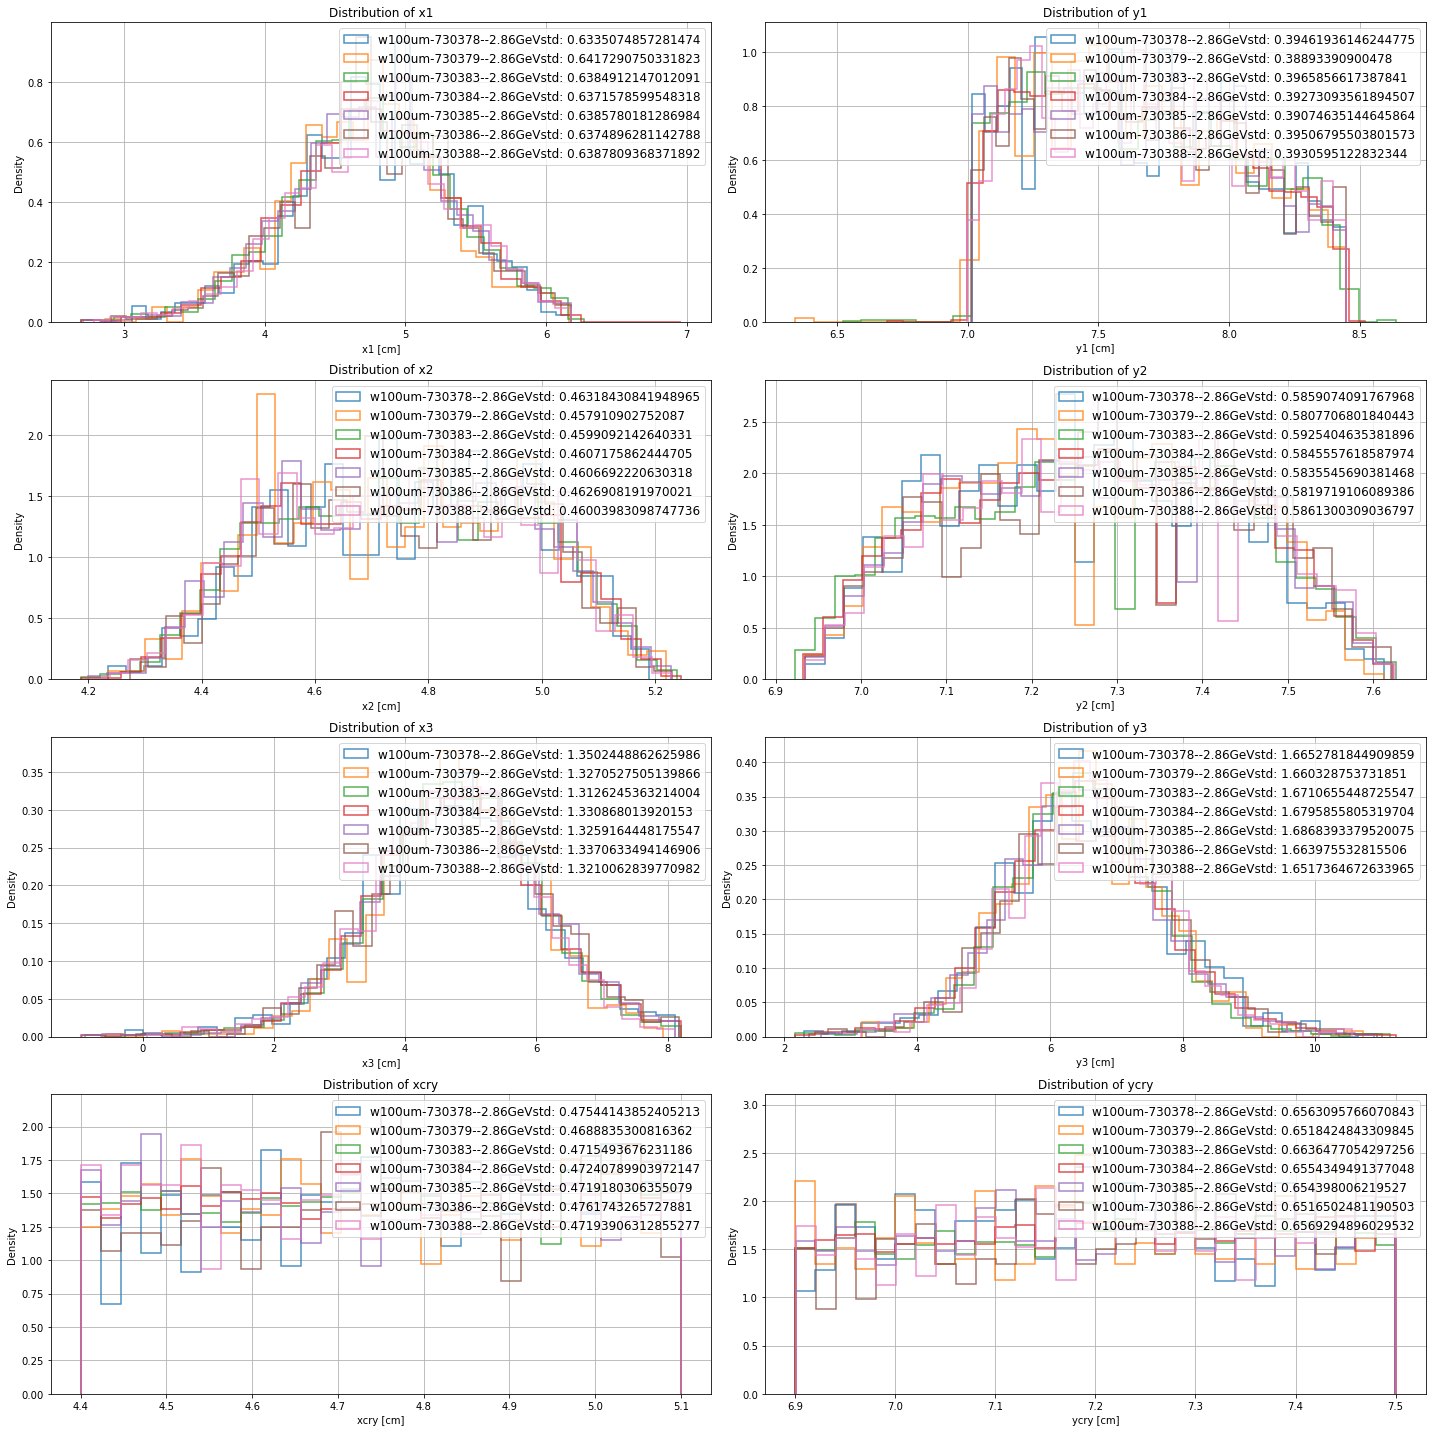

In [4]:
# Estrai tutti i run (senza raggruppamento per tipo)
all_runs = sorted(set(run for runs in group_by_type.values() for run in runs))

fig, axs = plt.subplots(4, 2, figsize=(20, 20))
axs = axs.flatten()

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'xcry', 'ycry']
colors = plt.cm.tab20(np.linspace(0, 1, len(all_runs)))

for j, run in enumerate(all_runs):
    label = f"{samples[run]}-{run}-{energies[run]}GeV"

    (_, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run)
    print(f'rot: {np.unique(xinfo[:,0])} -- crad: {np.unique(xinfo[:,1])}')
    x_cry_cut = x_cry_cuts[run]
    y_cry_cut = y_cry_cuts[run]
    theta_cut = theta_cut_dict[run]

    # Maschera selezione
    mask = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        (nclu[:, 0] == 1) &  (nclu[:, 1] == 1)
    )

    # Lista dati
    data_list = [x1, y1, x2, y2, x3, y3, xcry, ycry]

    for i, data in enumerate(data_list):
        axs[i].hist(data[mask], bins=30, label=label + f'std: {np.std(data)}', density=True, **opt_hist)

# === Aggiunte finali ===
for i in range(8):
    axs[i].set_xlabel(labels[i] + ' [cm]')
    axs[i].set_ylabel('Density')
    axs[i].set_title(f'Distribution of {labels[i]}')
    axs[i].grid(True)
    axs[i].legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()


Run 730378 — N spill: 103 — events: 7783 — evs/spill: 76
Run 730384 — N spill: 796 — events: 69263 — evs/spill: 87
Run 730385 — N spill: 212 — events: 18204 — evs/spill: 86
[730378, 730384, 730385] — TOTAL SPILLS: 1111 — TOTAL EVENTS: 95209
Run 730379 — N spill: 166 — events: 8032 — evs/spill: 48
Run 730383 — N spill: 626 — events: 40935 — evs/spill: 65
[730379, 730383] — TOTAL SPILLS: 792 — TOTAL EVENTS: 48940
Run 730386 — N spill: 105 — events: 8893 — evs/spill: 85
[730386] — TOTAL SPILLS: 105 — TOTAL EVENTS: 8889
Run 730388 — N spill: 106 — events: 9470 — evs/spill: 89
[730388] — TOTAL SPILLS: 106 — TOTAL EVENTS: 9464


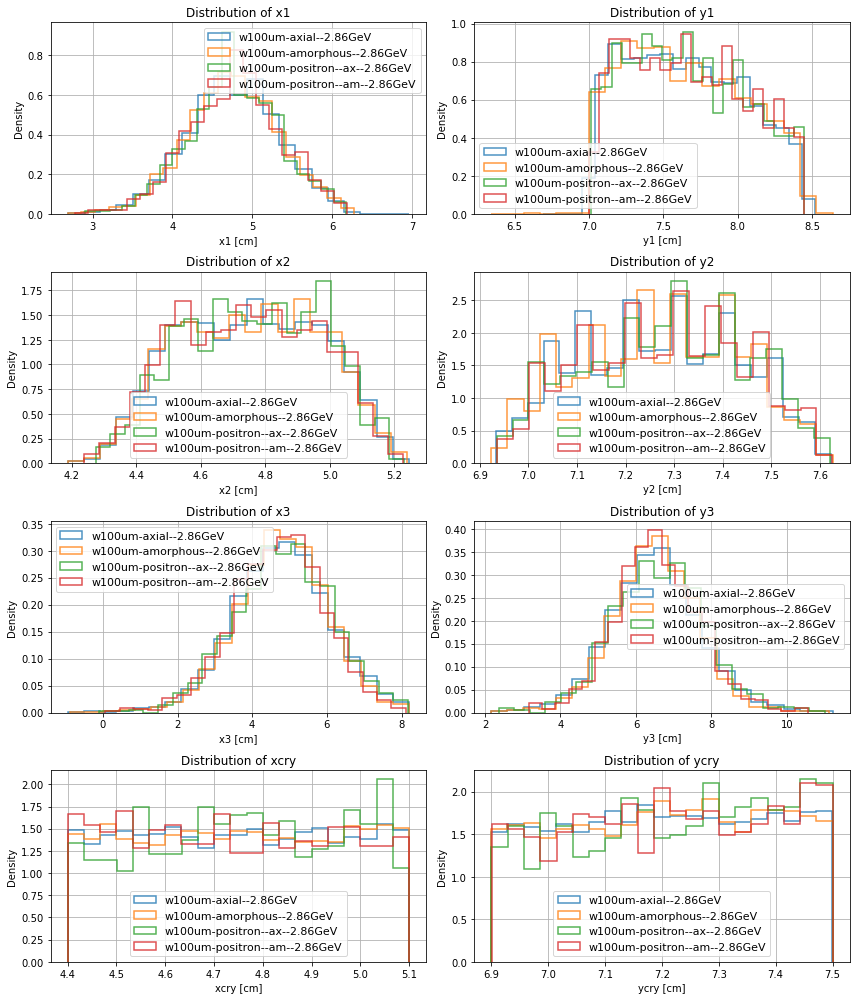

In [5]:
fig, axs = plt.subplots(4, 2, figsize=(12, 14))
axs = axs.flatten()

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3', 'xcry', 'ycry']
colors = plt.cm.tab20(np.linspace(0, 1, len(group_by_type)))

for j, (typ, run_list) in enumerate(group_by_type.items()):
    ref_run = run_list[0]
    label = f"{samples[ref_run]}-{typ}-{energies[ref_run]}GeV"
    
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run_list)

    x_cry_cut = run_config[str(ref_run)]["x_cry_cut"]
    y_cry_cut = run_config[str(ref_run)]["y_cry_cut"]
    theta_cut = theta_cut_dict[ref_run]

    mask = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        (nclu[:, 0] == 1) &  (nclu[:, 1] == 1)
    )

    data_list = [x1, y1, x2, y2, x3, y3, xcry, ycry]

    for i, data in enumerate(data_list):
        axs[i].hist(data[mask], bins=21, label=label, density=True, **opt_hist)

# === Etichette, griglia e legenda ===
for i in range(8):
    axs[i].set_xlabel(labels[i] + ' [cm]')
    axs[i].set_ylabel('Density')
    axs[i].set_title(f'Distribution of {labels[i]}')
    axs[i].grid(True)
    axs[i].legend(fontsize=11)

plt.tight_layout()
plt.show()



🔍 Analisi Type = axial
Run 730378 — N spill: 103 — events: 7783 — evs/spill: 76
Run 730384 — N spill: 796 — events: 69263 — evs/spill: 87
Run 730385 — N spill: 212 — events: 18204 — evs/spill: 86
[730378, 730384, 730385] — TOTAL SPILLS: 1111 — TOTAL EVENTS: 95209
Run 730378 -- w100um -2.86GeV: Δx = 0.700 cm, Δy = 0.600 cm, Area = 0.420 cm²
events after cuts: 9689, discarded events : 89.82%


🔍 Analisi Type = amorphous
Run 730379 — N spill: 166 — events: 8032 — evs/spill: 48
Run 730383 — N spill: 626 — events: 40935 — evs/spill: 65
[730379, 730383] — TOTAL SPILLS: 792 — TOTAL EVENTS: 48940
Run 730379 -- w100um -2.86GeV: Δx = 0.700 cm, Δy = 0.600 cm, Area = 0.420 cm²
events after cuts: 4936, discarded events : 89.91%


🔍 Analisi Type = positron--ax
Run 730386 — N spill: 105 — events: 8893 — evs/spill: 85
[730386] — TOTAL SPILLS: 105 — TOTAL EVENTS: 8889
Run 730386 -- w100um -2.86GeV: Δx = 0.700 cm, Δy = 0.600 cm, Area = 0.420 cm²
events after cuts: 810, discarded events : 90.89%


🔍 Ana

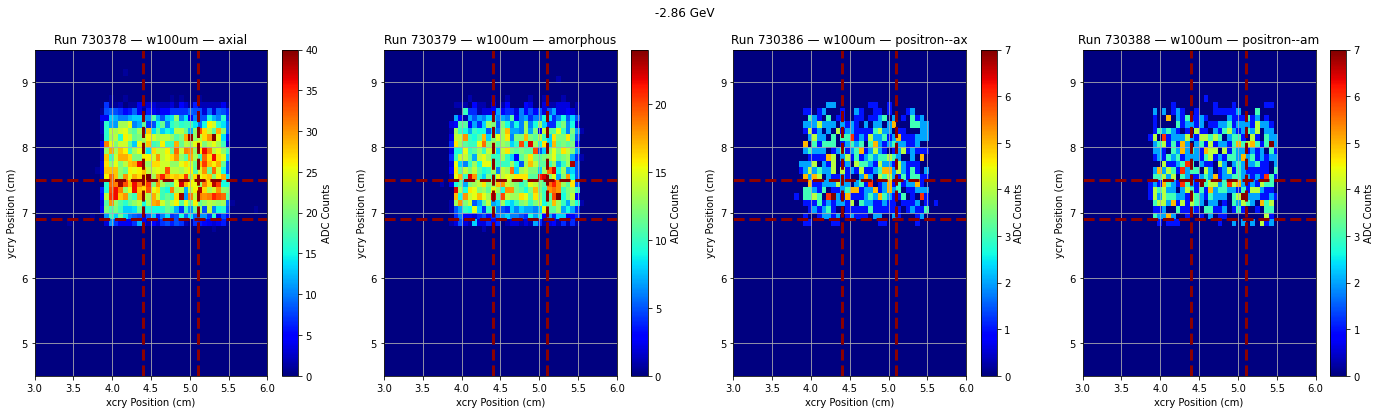

In [6]:
import matplotlib.pyplot as plt

n_types = len(group_by_type)
fig, ax = plt.subplots(1, n_types, figsize=(6 * n_types, 6), squeeze=False)
fig.suptitle(f' {energies[ref_run]} GeV')
ax = ax[0]  # flat access, so you can use ax[j]

for j, (typ, run) in enumerate(group_by_type.items()):
    print(f"\n🔍 Analisi Type = {typ}")
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run)

    ref_run = run[0]  # 👈 usa il primo run per i parametri di configurazione

    # === Build selection mask ===
    mask = (
        (ph_cherry1 > th_cherry1) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2)) &
        (nclu[:, 0] == 1) &  (nclu[:, 1] == 1)
    )

    # === Plot 2D histogram ===
    h = ax[j].hist2d(
        xcry[mask], ycry[mask],
        range=((3, 6), (4.5 ,9.5 )),
        cmap=mycmap,
        bins=50
    )

    # === Decorations ===
    ax[j].set_title(f"Run {ref_run} — {samples[ref_run]} — {types[ref_run]}")
    ax[j].set_xlabel("xcry Position (cm)")
    ax[j].set_ylabel("ycry Position (cm)")
    ax[j].grid(True)

    # === Show selection box ===
    x_min, x_max = x_cry_cuts[ref_run]
    y_min, y_max = y_cry_cuts[ref_run]
    dx, dy = x_max - x_min, y_max - y_min
    ax[j].axvline(x=x_min, color='darkred', linestyle='--', lw=3)
    ax[j].axvline(x=x_max, color='darkred', linestyle='--', lw=3)
    ax[j].axhline(y=y_min, color='darkred', linestyle='--', lw=3)
    ax[j].axhline(y=y_max, color='darkred', linestyle='--', lw=3)

    # === Print area info ===
    print(f"Run {ref_run} -- {samples[ref_run]} {energies[ref_run]}GeV: Δx = {dx:.3f} cm, Δy = {dy:.3f} cm, Area = {dx * dy:.3f} cm²")
    print(f'events after cuts: {np.sum(mask)}, discarded events : {100*(1-np.sum(mask)/np.size(mask)):.2f}%\n')
    
    # === Add colorbar ===
    plt.colorbar(h[3], ax=ax[j], label='ADC Counts')
plt.show()

Run 730378 — N spill: 103 — events: 7783 — evs/spill: 76
Run 730384 — N spill: 796 — events: 69263 — evs/spill: 87
Run 730385 — N spill: 212 — events: 18204 — evs/spill: 86
[730378, 730384, 730385] — TOTAL SPILLS: 1111 — TOTAL EVENTS: 95209
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730379 — N spill: 166 — events: 8032 — evs/spill: 48
Run 730383 — N spill: 626 — events: 40935 — evs/spill: 65
[730379, 730383] — TOTAL SPILLS: 792 — TOTAL EVENTS: 48940
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 100000000000.0
Run 730386 — N spill: 105 — events: 8893 — evs/spill: 85
[730386] — TOTAL SPILLS: 105 — TOTAL EVENTS: 8889
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188
Run 730388 — N spill: 106 — events: 9470 — evs/spill: 89
[730388] — TOTAL SPILLS: 106 — TOTAL EVENTS: 9464
Cuts: x [4.4, 5.1] -- y [6.9, 7.5] -- theta 0.0007875783899268188


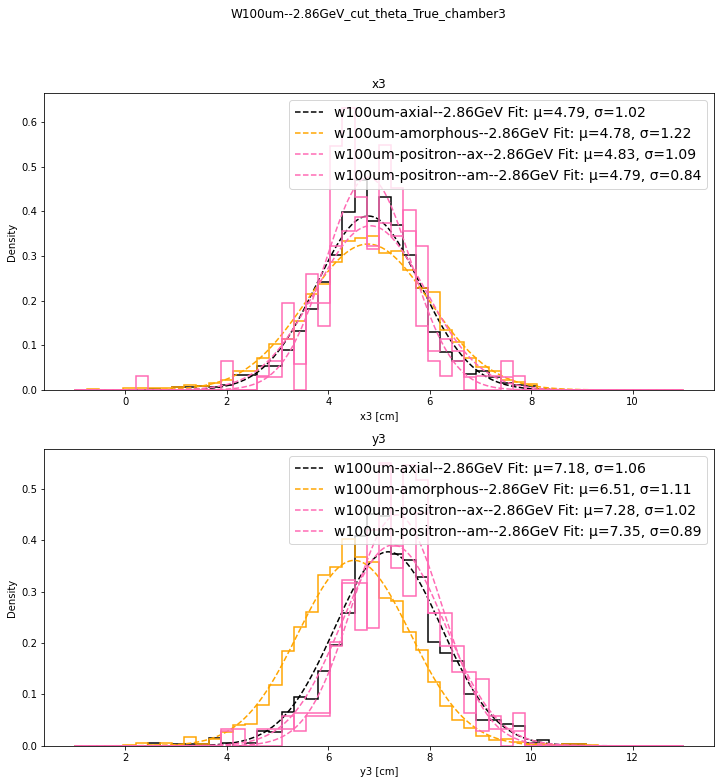

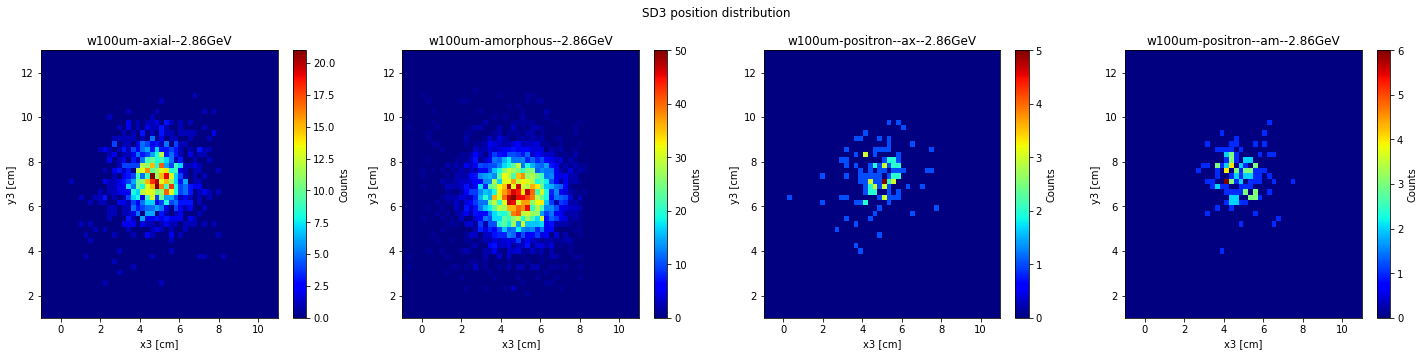

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

opt_hist = dict(histtype='step', linewidth=1.5)

fig, axs = plt.subplots(2, figsize=(12, 12))
fig.suptitle(f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_chamber3')
axs = axs.flatten()

fig2, ax2 = plt.subplots(1,len(group_by_type.items()), figsize=(5*len(group_by_type.items()),5))
fig2.suptitle('SD3 position distribution')

means_nclu3 = {}
means_qtot3 = {}
events = {}

for j, (typ, run_list) in enumerate(group_by_type.items()):
    ref_run = run_list[0]
    label = f"{samples[ref_run]}-{typ}-{energies[ref_run]}GeV"

    # === Load all runs in the group ===
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run_list)

    # === Get cuts ===
    x_cry_cut = run_config[str(ref_run)]["x_cry_cut"]
    y_cry_cut = run_config[str(ref_run)]["y_cry_cut"]
    theta_cut = theta_cut_dict[ref_run]
    print(f'Cuts: x {x_cry_cut} -- y {y_cry_cut} -- theta {theta_cut}')
    # === Selection mask ===
    logi = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2)) &
        (nclu[:, 0] == 1) &  (nclu[:, 1] == 1)
    )
    events[label] = np.sum(logi)

    if np.sum(logi) == 0:
        continue

    color = get_color(typ)

    # === x3 ===
    x_data = x3[logi]
    axs[0].hist(x_data, bins=50, range=(-1, 11), density=True,
                color=color, **opt_hist)

    mu_x, sigma_x = norm.fit(x_data)
    x_range = np.linspace(-1, 11, 500)
    axs[0].plot(x_range, norm.pdf(x_range, mu_x, sigma_x),
                linestyle='--', color=color,
                label=f"{label} Fit: μ={mu_x:.2f}, σ={sigma_x:.2f}")

    # === y3 ===
    y_data = y3[logi]
    axs[1].hist(y_data, bins=50, range=(1, 13), density=True,
                color=color, **opt_hist)

    mu_y, sigma_y = norm.fit(y_data)
    y_range = np.linspace(1, 13, 500)
    axs[1].plot(y_range, norm.pdf(y_range, mu_y, sigma_y),
                linestyle='--', color=color,
                label=f"{label} Fit: μ={mu_y:.2f}, σ={sigma_y:.2f}")

    valid = logi & (nclu[:, 0] > 0)
    means_nclu3[label] = np.mean(nclu[:, 0][valid])
    means_qtot3[label] = np.mean(qtot[:, 0][valid])



    h2d = ax2[j].hist2d(x_data, y_data, bins=50, range=((-1, 11), (1, 13)), cmap=mycmap)
    ax2[j].set_title(label)
    ax2[j].set_xlabel('x3 [cm]')
    ax2[j].set_ylabel('y3 [cm]')
    plt.colorbar(h2d[3], ax=ax2[j], label='Counts')

# === Titles and labels ===
axs[0].set_title('x3')
axs[1].set_title('y3')

labels = ['x3 [cm]', 'y3 [cm]']
for j in range(2):
    axs[j].set_xlabel(labels[j])
    axs[j].set_ylabel('Density')
    axs[j].legend(fontsize=14, loc='best')
    # axs[j].set_yscale('log')

plt.tight_layout()
plt.show()


Run 730378 — N spill: 103 — events: 7783 — evs/spill: 76
Run 730384 — N spill: 796 — events: 69263 — evs/spill: 87
Run 730385 — N spill: 212 — events: 18204 — evs/spill: 86
[730378, 730384, 730385] — TOTAL SPILLS: 1111 — TOTAL EVENTS: 95209
Run 730379 — N spill: 166 — events: 8032 — evs/spill: 48
Run 730383 — N spill: 626 — events: 40935 — evs/spill: 65
[730379, 730383] — TOTAL SPILLS: 792 — TOTAL EVENTS: 48940
Run 730386 — N spill: 105 — events: 8893 — evs/spill: 85
[730386] — TOTAL SPILLS: 105 — TOTAL EVENTS: 8889
Run 730388 — N spill: 106 — events: 9470 — evs/spill: 89
[730388] — TOTAL SPILLS: 106 — TOTAL EVENTS: 9464


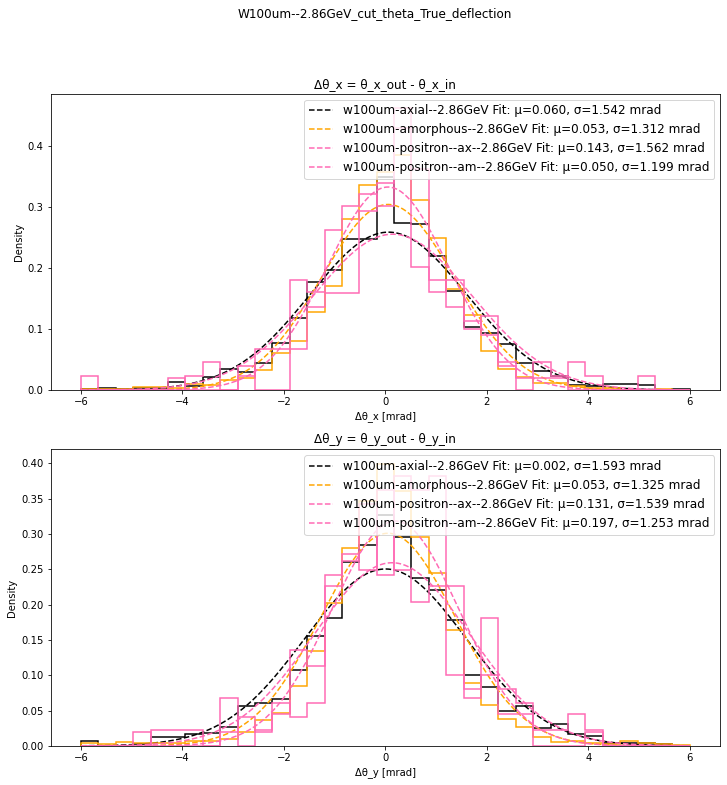

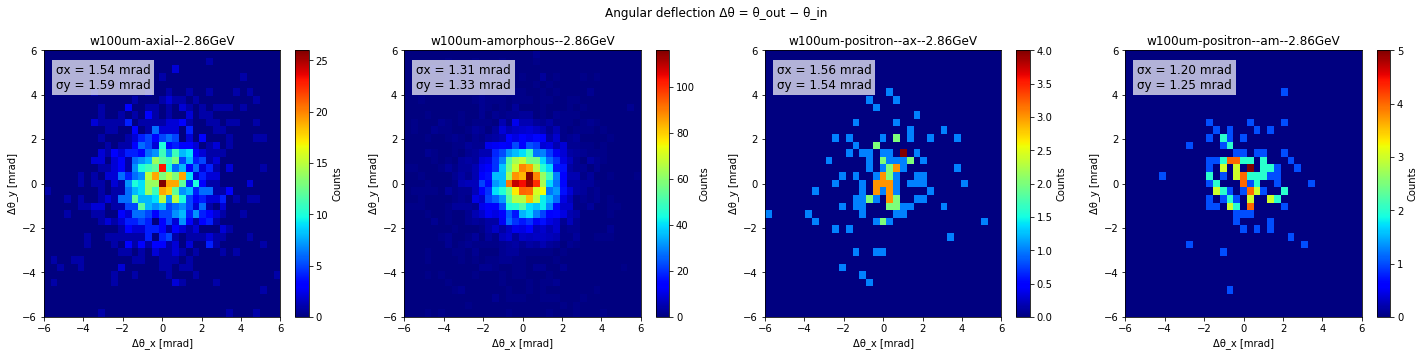

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

opt_hist = dict(histtype='step', linewidth=1.5)

fig_dtheta, axs_dtheta = plt.subplots(2, figsize=(12, 12))
fig_dtheta.suptitle(f'{target_sample}-{target_energy}GeV_cut_theta_{CutTheta}_deflection')
axs_dtheta = axs_dtheta.flatten()

fig_dtheta2, ax_dtheta2 = plt.subplots(1, len(group_by_type.items()), figsize=(5 * len(group_by_type.items()), 5))
fig_dtheta2.suptitle('Angular deflection Δθ = θ_out − θ_in')

for j, (typ, run_list) in enumerate(group_by_type.items()):
    ref_run = run_list[0]
    label = f"{samples[ref_run]}-{typ}-{energies[ref_run]}GeV"

    # === Load data ===
    (xpos, x1, y1, x2, y2, x3, y3, xcry, ycry, ph_calo_photon, ph_cherry1,
     theta_x_in, theta_y_in, theta_x_out, theta_y_out, tm, qtot, nclu,
     info_plus, xinfo) = file_loader(run_list)

    x_cry_cut = run_config[str(ref_run)]["x_cry_cut"]
    y_cry_cut = run_config[str(ref_run)]["y_cry_cut"]
    theta_cut = theta_cut_dict[ref_run]

    logi = (
        (ph_cherry1 > th_cherry1) &
        (xcry > x_cry_cut[0]) & (xcry < x_cry_cut[1]) &
        (ycry > y_cry_cut[0]) & (ycry < y_cry_cut[1]) &
        ((theta_x_in**2 + theta_y_in**2) < (theta_cut**2)) &
        (nclu[:, 0] == 1)  & (nclu[:, 1] == 1)
    )

    if np.sum(logi) == 0:
        continue

    color = get_color(typ)

    # === Compute deflection in mrad ===
    dtheta_x = (theta_x_out[logi] - theta_x_in[logi]) * 1e3
    dtheta_y = (theta_y_out[logi] - theta_y_in[logi]) * 1e3

    # === Plot Δθ_x ===
    axs_dtheta[0].hist(dtheta_x, bins=35, range=(-6, 6),
                       density=True, color=color, **opt_hist)
    mu_dx, sigma_dx = norm.fit(dtheta_x)
    x_range = np.linspace(-6, 6, 500)
    axs_dtheta[0].plot(x_range, norm.pdf(x_range, mu_dx, sigma_dx),
                       linestyle='--', color=color,
                       label=f"{label} Fit: μ={mu_dx:.3f}, σ={sigma_dx:.3f} mrad")

    # === Plot Δθ_y ===
    axs_dtheta[1].hist(dtheta_y, bins=35, range=(-6, 6), 
                       density=True, color=color, **opt_hist)
    mu_dy, sigma_dy = norm.fit(dtheta_y)
    y_range = np.linspace(-6, 6, 500)
    axs_dtheta[1].plot(y_range, norm.pdf(y_range, mu_dy, sigma_dy),
                       linestyle='--', color=color,
                       label=f"{label} Fit: μ={mu_dy:.3f}, σ={sigma_dy:.3f} mrad")

    # === Plot 2D histogram of deflections ===
    h2d = ax_dtheta2[j].hist2d(dtheta_x, dtheta_y, bins=35,
                               range=((-6, 6), (-6, 6)), cmap=mycmap)
    ax_dtheta2[j].set_title(label)
    ax_dtheta2[j].set_xlabel('Δθ_x [mrad]')
    ax_dtheta2[j].set_ylabel('Δθ_y [mrad]')    
    plt.colorbar(h2d[3], ax=ax_dtheta2[j], label='Counts')

    ax_dtheta2[j].text(
    0.05, 0.95,
    f"σx = {sigma_dx:.2f} mrad\nσy = {sigma_dy:.2f} mrad",
    transform=ax_dtheta2[j].transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
)
    
# === Labels and layout ===
axs_dtheta[0].set_title('Δθ_x = θ_x_out - θ_x_in')
axs_dtheta[1].set_title('Δθ_y = θ_y_out - θ_y_in')
axs_dtheta[0].set_xlabel('Δθ_x [mrad]')
axs_dtheta[1].set_xlabel('Δθ_y [mrad]')
axs_dtheta[0].set_ylabel('Density')
axs_dtheta[1].set_ylabel('Density')
axs_dtheta[0].legend(fontsize=12)
axs_dtheta[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
"730224":  {
        "x_cry_cut": [4.5, 5],
        "y_cry_cut": [7, 7.5],
        "sample": "W12mm",
        "type": "Amorphous",
        "energy": "-6"
    },
    "730256": {
        "x_cry_cut": [4.5, 5],
        "y_cry_cut": [7, 7.5],
        "sample": "W0.1mm",
        "type": "Amorphous",
        "energy": "-6"
    ,